In [2]:
import pandas as pd
import numpy as np
from datetime import timedelta 

In [3]:
# -------------------------------
# 1. Load datasets
# -------------------------------
admissions = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/admissions.csv", parse_dates=["admittime", "dischtime"])
diagnoses = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/diagnoses_icd.csv")
procedures = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/procedures_icd.csv")
patients = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/patients.csv", parse_dates=["anchor_year_group"])
edstays = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/mimic-iv-ed-2.2/ed/edstays.csv", parse_dates=["intime", "outtime"])
discharge = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/discharge.csv", parse_dates=["charttime", "storetime"])
hcpcsevents = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/hcpcsevents.csv")


/var/folders/p7/9c6q1htd3w3c0w7nfbmyv7zm0000gn/T/ipykernel_43258/2603204448.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  patients = pd.read_csv("/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/patients.csv", parse_dates=["anchor_year_group"])


In [4]:
# --- Standardize columns ---
admissions = admissions.rename(columns={
    "admittime": "admit_time",
    "dischtime": "discharge_time"
})
edstays = edstays.rename(columns={
    "intime": "admit_time",
    "outtime": "discharge_time"
})


In [5]:
# Add visit type
admissions["visit_type"] = "hospital"
edstays["visit_type"] = "emergency dept"

In [6]:

# Keep only necessary columns
admissions = admissions[["subject_id", "hadm_id", "admit_time", "discharge_time", "visit_type"]]
edstays = edstays[["subject_id", "hadm_id", "stay_id", "admit_time", "discharge_time", "visit_type"]]


In [7]:

visits = pd.concat([admissions, edstays], ignore_index=True)


In [8]:
# Sort and rank visits
visits = visits.sort_values(["subject_id", "admit_time"]).reset_index(drop=True)
visits["visit_number"] = visits.groupby("subject_id").cumcount() + 1

In [9]:
# --- Merge with patients ---
merged = visits.merge(patients[["subject_id", "gender", "anchor_age", "anchor_year"]], on="subject_id", how="left")

In [10]:
# --- Compute age at visit ---
def compute_age(subject_id, visit_time):
    row = patients[patients.subject_id == subject_id].iloc[0]
    return int(row["anchor_age"] + (visit_time.year - row["anchor_year"]))

merged.head()

,subject_id,hadm_id,admit_time,discharge_time,visit_type,stay_id,visit_number,gender,anchor_age,anchor_year
0,10000032,22595853.0,2180-05-06 19:17:00,2180-05-06 23:30:00,emergency dept,33258284.0,1,F,52.0,2180.0
1,10000032,22595853.0,2180-05-06 22:23:00,2180-05-07 17:15:00,hospital,NaN,2,F,52.0,2180.0
2,10000032,22841357.0,2180-06-26 15:54:00,2180-06-26 21:31:00,emergency dept,38112554.0,3,F,52.0,2180.0
3,10000032,22841357.0,2180-06-26 18:27:00,2180-06-27 18:49:00,hospital,NaN,4,F,52.0,2180.0
4,10000032,29079034.0,2180-07-22 16:24:00,2180-07-23 05:54:00,emergency dept,32952584.0,5,F,52.0,2180.0


In [11]:
# --- Visit date and time ---
merged["admit_date"] = merged["admit_time"].dt.date
merged["discharge_date"] = merged["discharge_time"].dt.date

In [12]:
# --- Length of stay ---
merged["los_days"] = (merged["discharge_time"] - merged["admit_time"]).dt.total_seconds() / (24 * 3600)

merged["visit_time_hrs"] = merged["admit_time"].dt.hour + merged["admit_time"].dt.minute / 60


In [13]:
def compute_age(subject_id, visit_time):
    row = patients[patients.subject_id == subject_id]
    if row.empty or pd.isnull(visit_time):
        return np.nan
    row = row.iloc[0]
    return int(row["anchor_age"] + (visit_time.year - row["anchor_year"]))


merged["age_at_visit"] = merged.apply(
    lambda x: compute_age(x["subject_id"], x["admit_time"]),
    axis=1
)


In [14]:
# --- Final tidy table ---
final = merged[[
    "subject_id", "hadm_id", "stay_id", "visit_number",
    "visit_type", "age_at_visit", "admit_date", "discharge_date", "visit_time_hrs"

]]

print(final.head(10))


   subject_id     hadm_id     stay_id  visit_number      visit_type  \
0    10000032  22595853.0  33258284.0             1  emergency dept   
1    10000032  22595853.0         NaN             2        hospital   
2    10000032  22841357.0  38112554.0             3  emergency dept   
3    10000032  22841357.0         NaN             4        hospital   
4    10000032  29079034.0  32952584.0             5  emergency dept   
5    10000032  29079034.0  39399961.0             6  emergency dept   
6    10000032  29079034.0         NaN             7        hospital   
7    10000032  25742920.0  35968195.0             8  emergency dept   
8    10000032  25742920.0         NaN             9        hospital   
9    10000068  25022803.0         NaN             1        hospital   

   age_at_visit  admit_date discharge_date  visit_time_hrs  
0          52.0  2180-05-06     2180-05-06       19.283333  
1          52.0  2180-05-06     2180-05-07       22.383333  
2          52.0  2180-06-26     218

In [15]:
# Combine all ICD codes per subject_id
diagnoses_icd_summary = (
    diagnoses.groupby("hadm_id")["icd_code"]
    .apply(lambda x: ', '.join(sorted(x.dropna().unique())))
    .reset_index(name="Diagnoses_ICD")
)


In [16]:
# Combine all ICD codes per subject_id
procedures_icd_summary = (
    diagnoses.groupby("hadm_id")["icd_code"]
    .apply(lambda x: ', '.join(sorted(x.dropna().unique())))
    .reset_index(name="Procedures_ICD")
)


In [17]:
cpt_summary = (
    hcpcsevents.groupby("hadm_id")["hcpcs_cd"]
    .apply(lambda x: ', '.join(sorted(x.dropna().unique())))
    .reset_index(name="CPT")
)

In [18]:
discharge_summary = discharge[['subject_id', 'hadm_id', 'text']].rename(
    columns={'text': 'discharge_notes'}
)
discharge_summary.head()


,subject_id,hadm_id,discharge_notes
0,10000032,22595853,\nName: ___ Unit No: _...
1,10000032,22841357,\nName: ___ Unit No: _...
2,10000032,29079034,\nName: ___ Unit No: _...
3,10000032,25742920,\nName: ___ Unit No: _...
4,10000084,23052089,\nName: ___ Unit No: __...


In [19]:
discharge_summary = (
    discharge.groupby(['subject_id', 'hadm_id'])['text']
    .apply(lambda x: ' '.join(x))
    .reset_index(name='discharge_notes')
)


In [20]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [21]:
import pandas as pd
from pathlib import Path

# Ensure visit_type is consistent
final['visit_type'] = final['visit_type'].str.lower()

# Get subject_ids with at least one ED visit
ed_subjects = (
    final[final['visit_type'] == 'emergency dept']
    ['subject_id']
    .dropna()
    .unique()
)


/var/folders/p7/9c6q1htd3w3c0w7nfbmyv7zm0000gn/T/ipykernel_43258/3511316940.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final['visit_type'] = final['visit_type'].str.lower()


In [24]:
import pandas as pd

# -------------------------------
# Most Common ICD Codes
# -------------------------------

# Count frequency of each ICD code
icd_counts = (
    diagnoses["icd_code"]
    .dropna()
    .value_counts()
    .reset_index()
)

# Rename columns
icd_counts.columns = ["icd_code", "n_occurrences"]

# Calculate percentage of total diagnoses
total_codes = icd_counts["n_occurrences"].sum()
icd_counts["percent"] = (
    icd_counts["n_occurrences"] / total_codes * 100
).round(2)

# Select top 20 most common codes
top_icd = icd_counts.head(20)

print(top_icd)

   icd_code  n_occurrences  percent
0      4019         102368     1.61
1      E785          84570     1.33
2       I10          83775     1.32
3      2724          67293     1.06
4    Z87891          62806     0.99
5      K219          56157     0.88
6     53081          48628     0.76
7     25000          43077     0.68
8      F329          41876     0.66
9     I2510          41550     0.65
10     F419          38911     0.61
11    42731          37070     0.58
12     4280          36606     0.58
13      311          36349     0.57
14    41401          36083     0.57
15     N179          35884     0.56
16   Z20822          33113     0.52
17    V1582          31705     0.50
18    Z7901          30957     0.49
19     5849          29136     0.46


In [26]:
# Load ICD dictionary
icd_dict = pd.read_csv(
    "/Users/jasleengandhi/Documents/MIMIC/mimic-iv-3-2.1/hosp/d_icd_diagnoses.csv"
)

# Keep relevant columns
icd_dict = icd_dict[["icd_code", "icd_version", "long_title"]]

In [27]:
# Count ICD codes with version (important for correct mapping)
icd_counts = (
    diagnoses
    .dropna(subset=["icd_code"])
    .groupby(["icd_code", "icd_version"])
    .size()
    .reset_index(name="n_occurrences")
    .sort_values("n_occurrences", ascending=False)
)

# Calculate percentage
total_codes = icd_counts["n_occurrences"].sum()
icd_counts["percent"] = (
    icd_counts["n_occurrences"] / total_codes * 100
).round(2)

In [32]:


# -------------------------------
# 2. Count ICD frequencies
# -------------------------------
icd_counts = (
    diagnoses
    .dropna(subset=["icd_code"])
    .groupby("icd_code")
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)

# Calculate percentage
total_codes = icd_counts["N"].sum()
icd_counts["Percent (%)"] = (icd_counts["N"] / total_codes * 100).round(2)

# -------------------------------
# 3. Merge with disease descriptions
# -------------------------------
top10 = icd_counts.merge(icd_dict, on="icd_code", how="left").head(10)

# -------------------------------
# 4. Clean column names
# -------------------------------
top10 = top10.rename(columns={
    "icd_code": "ICD Code",
    "long_title": "Disease Description"
})

# Add rank
top10 = top10.reset_index(drop=True)
top10.index += 1
top10.insert(0, "Rank", top10.index)

# Format counts with commas
top10["N"] = top10["N"].map("{:,}".format)

# -------------------------------
# 5. Save publication-ready table
# -------------------------------
top10.to_csv("Top10_ICD_Table.csv", index=False)

# Optional: LaTeX table
latex_table = top10.to_latex(
    index=False,
    caption="Top 10 Most Common ICD Diagnoses in the Cohort",
    label="tab:top10_icd"
)

with open("Top10_ICD_Table.tex", "w") as f:
    f.write(latex_table)

print("✅ Top 10 ICD table saved.")
print(top10)

✅ Top 10 ICD table saved.
    Rank ICD Code        N  Percent (%)  icd_version  \
1      1     4019  102,368         1.61            9   
2      2     E785   84,570         1.33           10   
3      3      I10   83,775         1.32           10   
4      4     2724   67,293         1.06            9   
5      5   Z87891   62,806         0.99           10   
6      6     K219   56,157         0.88           10   
7      7    53081   48,628         0.76            9   
8      8    25000   43,077         0.68            9   
9      9     F329   41,876         0.66           10   
10    10    I2510   41,550         0.65           10   

                                  Disease Description  
1                  Unspecified essential hypertension  
2                         Hyperlipidemia, unspecified  
3                    Essential (primary) hypertension  
4                Other and unspecified hyperlipidemia  
5             Personal history of nicotine dependence  
6   Gastro-esophageal

In [35]:
# Number of visits per patient
visit_stats = final.groupby("subject_id").agg(
    n_visits=("visit_number", "max"),
    n_ed_visits=("visit_type", lambda x: (x == "emergency dept").sum()),
    n_hosp_visits=("visit_type", lambda x: (x == "hospital").sum())
  
).reset_index()

# Summary table
summary_table = visit_stats.agg(
    mean_visits=("n_visits", "mean"),
    median_visits=("n_visits", "median"),
    min_visits=("n_visits", "min"),
    max_visits=("n_visits", "max")
)

print(summary_table)
summary_table.to_csv("table_visit_statistics.csv")

                 n_visits
mean_visits      3.206471
median_visits    2.000000
min_visits       1.000000
max_visits     559.000000


Total patients: 302,861
Total visits: 971,141
               Category   Count
0              Patients  302861
1  Hospital + ED Visits  971141


/var/folders/p7/9c6q1htd3w3c0w7nfbmyv7zm0000gn/T/ipykernel_43258/1192910393.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Count", data=summary_df, palette="Blues_d")


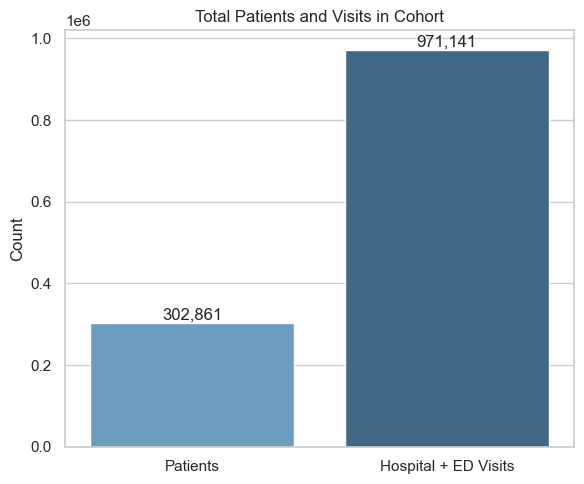

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Calculate total patients
# -------------------------------
total_patients = final["subject_id"].nunique()
print(f"Total patients: {total_patients:,}")

# -------------------------------
# 2. Calculate total visits
# -------------------------------
total_visits = final["hadm_id"].nunique()  # hospital admissions
total_ed_visits = final["stay_id"].notna().sum()  # ED visits with stay_id
total_visits_all = total_visits + total_ed_visits
print(f"Total visits: {total_visits_all:,}")

# -------------------------------
# 3. Create summary table
# -------------------------------
summary_df = pd.DataFrame({
    "Category": ["Patients", "Hospital + ED Visits"],
    "Count": [total_patients, total_visits_all]
})

print(summary_df)
summary_df.to_csv("summary_total_patients_visits.csv", index=False)

# -------------------------------
# 4. Visualization: bar plot
# -------------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(6,5))
sns.barplot(x="Category", y="Count", data=summary_df, palette="Blues_d")
plt.title("Total Patients and Visits in Cohort")
plt.ylabel("Count")
plt.xlabel("")
for index, row in summary_df.iterrows():
    plt.text(index, row.Count + total_visits_all*0.01, f"{row.Count:,}", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("fig_total_patients_visits.png", dpi=300)
plt.show()

/var/folders/p7/9c6q1htd3w3c0w7nfbmyv7zm0000gn/T/ipykernel_43258/1458059765.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="visit_type", y="Count", data=summary_df, palette="Blues_d")
posx and posy should be finite values
posx and posy should be finite values


Total patients: 302,861
        visit_type  n_visits     Count
0   Total Patients  302861.0       NaN
1        ED Visits       NaN  425087.0
2  Hospital Visits       NaN  546028.0


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


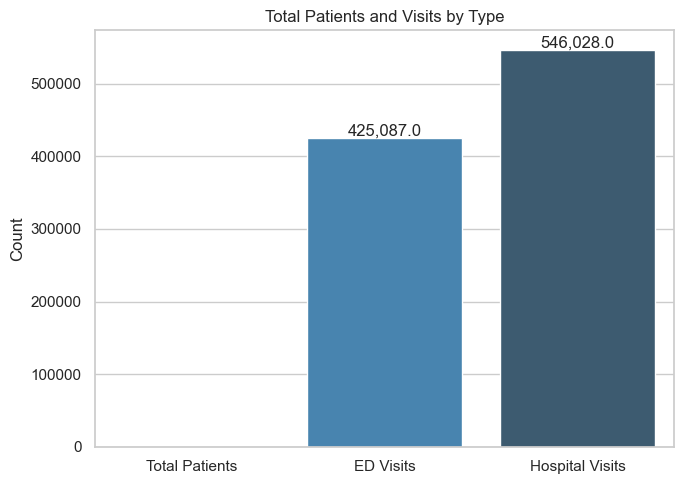

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Count total patients
# -------------------------------
total_patients = final["subject_id"].nunique()
print(f"Total patients: {total_patients:,}")

# -------------------------------
# 2. Count visits by type
# -------------------------------
visit_counts = final.groupby("visit_type").agg(
    n_visits=("visit_number", "count")
).reset_index()

# Replace type names for clarity
visit_counts["visit_type"] = visit_counts["visit_type"].replace({
    "hospital": "Hospital Visits",
    "emergency dept": "ED Visits"
})

# Add total patients as a separate row
summary_df = pd.concat([
    pd.DataFrame({"visit_type": ["Total Patients"], "n_visits": [total_patients]}),
    visit_counts.rename(columns={"visit_type": "visit_type", "n_visits": "Count"}).rename(columns={"n_visits":"Count"})
], ignore_index=True)

print(summary_df)
summary_df.to_csv("summary_patients_vs_visits.csv", index=False)

# -------------------------------
# 3. Visualization: bar plot
# -------------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(7,5))
sns.barplot(x="visit_type", y="Count", data=summary_df, palette="Blues_d")
plt.title("Total Patients and Visits by Type")
plt.ylabel("Count")
plt.xlabel("")
for index, row in summary_df.iterrows():
    plt.text(index, row.Count + total_patients*0.01, f"{row.Count:,}", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig("fig_patients_vs_visits.png", dpi=300)
plt.show()

In [22]:
# If you want reproducibility
import numpy as np
np.random.seed(42)

selected_subjects = np.random.choice(
    ed_subjects,
    size=100,
    replace=False
)


In [23]:
# Output directory
output_dir = Path("/Users/jasleengandhi/Documents/DBMI/MIMIC/output_patients")
output_dir.mkdir(exist_ok=True)

for subject_id in selected_subjects:
    # Create subject folder
    subject_folder = output_dir / str(subject_id)
    subject_folder.mkdir(exist_ok=True)

    # Get all visits for this subject
    subject_visits = final[final['subject_id'] == subject_id]

    # Save visit information
    subject_visits.to_csv(
        subject_folder / "visits.csv",
        index=False
    )


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jasleengandhi/Documents/DBMI/MIMIC/output_patients'

In [ ]:
discharge_summary = (
    discharge.groupby(['subject_id', 'hadm_id'])['note_text']
    .apply(lambda x: ' '.join(x))
    .reset_index(name='discharge_notes')
)


KeyError: 'Column not found: note_text'

In [ ]:
# -------------------------------
# 3. Hospital events
# -------------------------------
hosp = admissions.copy()
hosp["event_id"] = "H-" + hosp["hadm_id"].astype(str)
hosp["type"] = "HOSP"
hosp["admittime"] = hosp["admittime"]
hosp["dischtime"] = hosp["dischtime"]

# Merge diagnoses
hosp_icd = diagnoses.groupby("hadm_id")["icd_code"].apply(list).reset_index()
hosp = hosp.merge(hosp_icd, on="hadm_id", how="left")
hosp["icd_count"] = hosp["icd_code"].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Merge procedures
hosp_proc = procedures.groupby("hadm_id")["icd_code"].apply(list).reset_index()
hosp = hosp.merge(hosp_proc, on="hadm_id", how="left", suffixes=("", "_proc"))
hosp["cpt_count"] = hosp["icd_code_proc"].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Notes
hosp_notes = notes[notes["text"] == "Discharge summary"].groupby("hadm_id")["note_id"].apply(list).reset_index()
hosp = hosp.merge(hosp_notes, on="hadm_id", how="left")
hosp["n_discharge_summaries_for_visit"] = hosp["note_id"].apply(lambda x: len(x) if isinstance(x, list) else 0)

KeyError: 'admittime'

In [ ]:
# -------------------------------
# 4. ED events
# -------------------------------
ed = edstays.copy()
ed["event_id"] = "ED-" + ed["stay_id"].astype(str)
ed["type"] = "ED"
ed.rename(columns={"intime": "admittime", "outtime": "dischtime"}, inplace=True)

# ED codes (toy example, depends on your ED tables)
ed["icd_code"] = [[] for _ in range(len(ed))]
ed["icd_count"] = 0
ed["cpt_count"] = 0

# ED notes
ed_notes = notes[notes["text"] == "ED"].groupby("hadm_id")["note_id"].apply(list).reset_index()
ed = ed.merge(ed_notes, on="hadm_id", how="left")
ed["n_ed_reports_for_visit"] = ed["note_id"].apply(lambda x: len(x) if isinstance(x, list) else 0)

NameError: name 'notes' is not defined

In [ ]:
# -------------------------------
# 5. Combine hospital + ED
# -------------------------------
events = pd.concat([
    hosp[["subject_id","event_id","type","admittime","dischtime","icd_code","icd_count","cpt_count"]],
    ed[["subject_id","event_id","type","admittime","dischtime","icd_code","icd_count","cpt_count"]]
], axis=0, ignore_index=True)


KeyError: "['admittime', 'dischtime', 'icd_code', 'icd_count', 'cpt_count'] not in index"

In [ ]:
# -------------------------------
# 6. Kidney flag
# -------------------------------
kidney_codes = {"5859","586","N18","N19","592", "5920", "5921", "5929", "N20", "N200", "N201", "N202", "N209"}  # extend as needed
def is_kidney_related(codes):
    if isinstance(codes, list):
        return int(any(str(c).startswith(tuple(kidney_codes)) for c in codes))
    return 0

events["kidney_flag"] = events["icd_code"].apply(is_kidney_related)

In [ ]:
# -------------------------------
# 7. Source column
# -------------------------------
events["source"] = events["type"].map({
    "HOSP": "hospitalization",
    "ED": "emergency department"
})

In [ ]:

# -------------------------------
# 8. Compute age at visit
# -------------------------------
def compute_age(subject_id, visit_time):
    row = patients[patients.subject_id == subject_id]
    if row.empty or pd.isnull(visit_time):
        return np.nan
    row = row.iloc[0]
    return int(row["anchor_age"] + (visit_time.year - row["anchor_year"]))

In [ ]:
# -------------------------------
# 9. Patient-level aggregation
# -------------------------------
patient_visits = (
    events.sort_values(["subject_id","admittime"])
    .groupby("subject_id")
    .apply(lambda x: x.to_dict(orient="records"))
    .reset_index()
    .rename(columns={0:"visits"})
)

# Add demographics
patient_df = patients.merge(patient_visits, on="subject_id", how="inner")

# Add total kidney visits
patient_df["n_kidney_visits"] = patient_df["visits"].apply(lambda v: sum(d["kidney_flag"] for d in v))

In [ ]:
# -------------------------------
# 10. Save output
# -------------------------------
patient_df.to_csv("patient_timeline.csv", index=False)
print(" Patient timeline saved to patient_timeline.csv")

In [ ]:

# 11 assume patient_df is your current dataframe with column `visits` (list of dicts)
# # 1. Explode visits list into multiple rows
expanded = patient_df.explode("visits").reset_index(drop=True)

# 2. Expand each dict in visits into columns
visits_norm = pd.json_normalize(expanded["visits"])

# 🚨 FIX: drop nested subject_id to avoid multi-dim groupby error
if "subject_id" in visits_norm.columns:
    visits_norm = visits_norm.drop(columns=["subject_id"])

expanded = pd.concat([expanded.drop(columns=["visits"]), visits_norm], axis=1)

# 3. Assign visit number per patient
expanded["visit_number"] = expanded.groupby("subject_id").cumcount() + 1


In [ ]:

# 4. Create a single descriptive string for each visit
expanded["visit_summary"] = (
    expanded["type"] + ", "
    + expanded["admittime"].astype(str) + "-" + expanded["dischtime"].astype(str) + ", "
    + "ICD=" + expanded["icd_count"].astype(str) + ", "
    + "CPT=" + expanded["cpt_count"].astype(str) + ", "
    + "Kidney=" + expanded["kidney_flag"].astype(str)
)

# 5. Pivot to wide format: one cell per visit
wide = expanded.pivot(
    index=["subject_id", "gender", "anchor_age", "anchor_year", "anchor_year_group", "dod"],
    columns="visit_number",
    values="visit_summary"
)

# 6. Rename columns as visit_1, visit_2, ...
wide.columns = [f"visit_{i}" for i in wide.columns]
wide = wide.reset_index()

# ---------------------------
# Save result
# ---------------------------
wide.to_csv("patient_timeline_wide.csv", index=False)
print("✅ Wide patient timeline saved to patient_timeline_wide.csv (1 cell per visit)")


In [ ]:
# -------------------------------
# 8. Compute age at visit
# -------------------------------
def compute_age(subject_id, visit_time):
    row = patients[patients.subject_id == subject_id]
    if row.empty or pd.isnull(visit_time):
        return np.nan
    row = row.iloc[0]
    return int(row["anchor_age"] + (visit_time.year - row["anchor_year"]))

# -------------------------------
# 9. Explode visits into rows
# -------------------------------
expanded = patient_df.explode("visits").reset_index(drop=True)

# 10. Normalize dict into columns
visits_norm = pd.json_normalize(expanded["visits"])

# ⚠️ Drop nested subject_id if present to prevent groupby errors
if "subject_id" in visits_norm.columns:
    visits_norm = visits_norm.drop(columns=["subject_id"])

expanded = pd.concat([expanded.drop(columns=["visits"]), visits_norm], axis=1)

# -------------------------------
# 11. Assign visit number
# -------------------------------
expanded["visit_number"] = expanded.groupby("subject_id").cumcount() + 1

# -------------------------------
# ✅ 12. Compute age per visit (NEW)
# -------------------------------
expanded["age_at_visit"] = expanded.apply(
    lambda row: compute_age(row["subject_id"], row["admittime"]), axis=1
)

# -------------------------------
# 13. Create descriptive visit summary (optional, or keep separate columns)
# -------------------------------
expanded["visit_summary"] = (
    "Age=" + expanded["age_at_visit"].astype(str) + ", "
    + expanded["type"] + ", "
    + expanded["admittime"].astype(str) + "→" + expanded["dischtime"].astype(str) + ", "
    + "ICD=" + expanded["icd_count"].astype(str) + ", "
    + "CPT=" + expanded["cpt_count"].astype(str) + ", "
    + "Kidney=" + expanded["kidney_flag"].astype(str)
)

# -------------------------------
# 14. Pivot to wide format
# -------------------------------
wide = expanded.pivot(
    index=["subject_id", "gender", "anchor_age", "anchor_year", "anchor_year_group", "dod"],
    columns="visit_number",
    values="visit_summary"
)

# -------------------------------
# 15. Rename visit columns
# -------------------------------
wide.columns = [f"visit_{i}" for i in wide.columns]
# Drop visit columns that are completely empty (NaN for all patients)
wide = wide.dropna(axis=1, how='all')

wide = wide.reset_index()

# -------------------------------
# 16. Save final CSV
# -------------------------------
wide.to_csv("patient_timeline_wide.csv", index=False)
print("✅ Wide patient timeline with per-visit age saved to patient_timeline_wide.csv")


In [ ]:
# Filter patients with at least one kidney-related visit
kidney_patients = expanded.groupby("subject_id").filter(lambda df: df["kidney_flag"].sum() > 0)
wide = wide.dropna(axis=1, how='all')
# Save as CSV
kidney_patients.to_csv("patients_with_kidney_visits_long.csv", index=False)
print("✅ Saved patients with ≥1 kidney-related visit (long format) to patients_with_kidney_visits_long.csv")


In [ ]:
# Calculate total kidney visits per patient
kidney_counts = expanded.groupby("subject_id")["kidney_flag"].sum().reset_index(name="n_kidney_visits")
wide = wide.dropna(axis=1, how='all')
# Merge with the wide table
wide_with_kidney = wide.merge(kidney_counts, on="subject_id", how="left")

# Filter patients with ≥1 kidney-related visit
kidney_wide = wide_with_kidney[wide_with_kidney["n_kidney_visits"] > 0]

# Save as CSV
kidney_wide.to_csv("patient_timeline_wide_kidney.csv", index=False)
print("✅ Saved wide patient timeline (only patients with ≥1 kidney visit) to patient_timeline_wide_kidney.csv")


In [ ]:
# ----------------------------------------
# Machine Learning Pipeline for Kidney Flag & Days Until Next Visit
# ----------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline


In [ ]:
# -------------------------------
# 1. Load dataset
# -------------------------------
df = pd.read_csv("/Users/jasleengandhi/Documents/DBMI/MIMIC/patient_timeline_wide_kidney.csv")

# Optional: drop completely empty columns
df = df.dropna(axis=1, how='all')
